# Trimer Case I: MCWF

## Preparation


**Parameters**

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from qutip import *

# Parameters
omega0 = 1.0
gamma0 = 0.1   # spontaneous emission rate
temperature = 1.0  # tempeature of photon gas
NT = 1/(np.exp(omega0/temperature)-1) # Planck distribution

gamma_a = gamma0 * NT   # coefficient to absorption
gamma_e = gamma0 * (NT+1)  # coefficient to emission


**Operators for N=3**

In [2]:
# Kronecker products of three operators
def kprod3(o1,o2,o3):
    return tensor(tensor(o1,o2),o3)

#--- Spin operators ---
i2 = qeye(2)
sz = [kprod3(sigmaz(),i2,i2),kprod3(i2,sigmaz(),i2),kprod3(i2,i2,sigmaz())]
sp = [kprod3(sigmap(),i2,i2),kprod3(i2,sigmap(),i2),kprod3(i2,i2,sigmap())]
sm = [kprod3(sigmam(),i2,i2),kprod3(i2,sigmam(),i2),kprod3(i2,i2,sigmam())]

#--- Hamiltonian ---
H = 0.5*omega0*np.sum(sz)

#--- Jump operators ---
c_ops = []
# absorption
for k in range(3):
    c_ops.append(np.sqrt(gamma_a)*sp[k])
# emission
for k in range(3):
    c_ops.append(np.sqrt(gamma_e)*sm[k])    


**Energy eigenstates**

In [3]:
label2=['e','g']
label8=[]
basis8=[]
#--- basis vectors and their name ---
for i1 in range(2):
    for i2 in range(2):
        for i3 in range(2):
            label8.append(label2[i1]+label2[i2]+label2[i3])
            basis8.append(kprod3(basis(2,i1),basis(2,i2),basis(2,i3)))


## Monte Carlo Wave Function

In [4]:
#--- the ground state as initial state
psi0 = basis8[7]

# execution time (trying to get 1000 photons)
tmax = 500 / gamma0
# number of time sampling points
tsample = 5000
times = np.linspace(0, tmax, tsample)

# options for mcsolver
opts={"store_states": True,"keep_runs_results": True, "progress_bar": False}

# get a trajectory
result = mcsolve(H,psi0,times,c_ops,e_ops=sz,ntraj=1,options=opts)

## Clicks

In [5]:
# get results
t_jump = np.array(result.col_times[0]) # time of all jumps
ch_jump = np.array(result.col_which[0]) # channel of all jumps

# absorption time for each emitters
ta_1 = t_jump[ch_jump==0]
ta_2 = t_jump[ch_jump==1]
ta_3 = t_jump[ch_jump==2]
ta_all = t_jump[(ch_jump==0) | (ch_jump==1) | (ch_jump==2)]

# emission time for each quantum dot
te_1 = t_jump[ch_jump==3]
te_2 = t_jump[ch_jump==4]
te_3 = t_jump[ch_jump==5]
te_all = t_jump[(ch_jump==3) | (ch_jump==4) | (ch_jump==5)]

print("** Jump counts  **")
print(" emitter 1: emission count={0:4d}   absorption count={1:4d}".format(np.size(te_1), np.size(ta_1)))
print(" emitter 2: emission count={0:4d}   absorption count={1:4d}".format(np.size(te_2), np.size(ta_2)))
print(" emitter 3: emission count={0:4d}   absorption count={1:4d}".format(np.size(te_3), np.size(ta_3)))
print("     total: emission count={0:4d}   absorption count={1:4d}".format(np.size(te_all), np.size(ta_all)))

** Jump counts  **
 emitter 1: emission count= 220   absorption count= 220
 emitter 2: emission count= 226   absorption count= 227
 emitter 3: emission count= 230   absorption count= 230
     total: emission count= 676   absorption count= 677


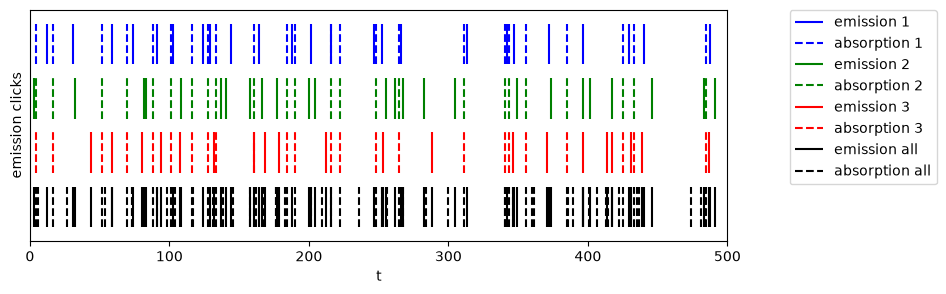

In [6]:
plt.figure(figsize=(9, 3))

# emissions: detector clicks
plt.vlines(te_1, 2.0, 2.75, color="b", label="emission 1")
plt.vlines(ta_1, 2.0, 2.75, color="b", ls='--',label="absorption 1")
plt.vlines(te_2, 1.0, 1.75, color="g", label="emission 2")
plt.vlines(ta_1, 1.0, 1.75, color="g", ls='--',label="absorption 2")
plt.vlines(te_3, 0.0, 0.75, color="r", label="emission 3")
plt.vlines(ta_1, 0.0, 0.75, color="r", ls='--',label="absorption 3")
plt.vlines(te_all, -1, -0.25, color="k", label="emission all")
plt.vlines(ta_all, -1, -0.25, color="k", ls='--',label="absorption all")

plt.ylabel("emission clicks")
plt.xlabel("t")
plt.xlim([0,500])
plt.ylim(-1.25, 3.0)
plt.yticks([])
plt.legend(bbox_to_anchor=(1.30, 1), borderaxespad=0)
plt.show()


## Quantum trajectories

The jump should be instantaneous but the jumps in the plot looks not instantaneous.  This is an artifact due to the discreet time used in the simulation.

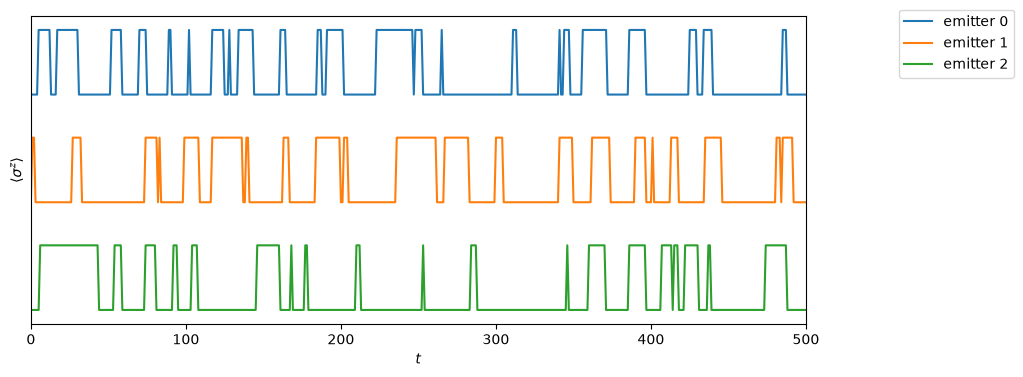

In [7]:
plt.figure(figsize=(10, 4))

p = [result.expect[k] for k in range(3)]

for k in range(3):
    plt.plot(times,p[k].flatten()*0.3+(3-k),label="emitter %d" % k)

plt.yticks([])
plt.ylabel(r"$\langle\sigma^z\rangle$")
plt.xlabel(r"$t$")
plt.legend(bbox_to_anchor=(1.12, 0.8), borderaxespad=0)
plt.xlim([0,500])
plt.show()

## Waiting time ditribution

In [8]:
tlist = np.linspace(0, 4000, 8000)

# the number of realizations
ntraj = 200

# MCWF
res = mcsolve(H, basis8[7], tlist, c_ops, e_ops=[], ntraj=ntraj,
              options={"keep_runs_results": True,"progress_bar": False})

# get waiting time 
wtime1 = []
wtime2 = []
wtime3 = []
wtimes = []
emit1 = []
emit2 = []
emit3 = []
emits = []
for k in range(ntraj):
    tj = np.asarray(res.col_times[k])  # accumulate all jumps
    ch = np.asarray(res.col_which[k])  # accumulate channel info

    # emitter 1 only
    emit = tj[(ch == 3)]
    wtime1.append(np.diff(emit))
    # emitter 2 only                         
    emit = tj[(ch == 4)]
    wtime2.append(np.diff(emit))
    # emitter 2 only                         
    emit = tj[(ch == 5)]
    wtime3.append(np.diff(emit))
    # all emitters
    emit = np.sort(tj[(ch == 3) | (ch == 4) | (ch == 5)])
    wtimes.append(np.diff(emit))

wtime1 = np.concatenate(wtime1)
wtime2 = np.concatenate(wtime2)
wtime3 = np.concatenate(wtime3)
wtimes = np.concatenate(wtimes)

print("Waiting time statistics")
print("emitter    photons   mean   deviation")
photons=wtime1.size
mean = wtime1.mean()
dev = np.sqrt((wtime1**2).mean() - mean**2)
print(" {0:5s}   {1:7d}   {2:7.3f}   {3:7.3f}".format("1", photons, mean, dev))
photons=wtime2.size
mean = wtime2.mean()
dev = np.sqrt((wtime2**2).mean() - mean**2)
print(" {0:5s}   {1:7d}   {2:7.3f}   {3:7.3f}".format("2", photons, mean, dev))
photons=wtime3.size
mean = wtime3.mean()
dev = np.sqrt((wtime3**2).mean() - mean**2)
print(" {0:5s}   {1:7d}   {2:7.3f}   {3:7.3f}".format("3", photons, mean, dev))
photons=wtimes.size
mean = wtimes.mean()
dev = np.sqrt((wtimes**2).mean() - mean**2)
print(" {0:5s}   {1:7d}   {2:7.3f}   {3:7.3f}".format("All", photons, mean, dev))

Waiting time statistics
emitter    photons   mean   deviation
 1         33721    23.458    18.286
 2         33862    23.388    18.298
 3         33758    23.446    18.351
 All      101741     7.829     6.739


**Waiting time distribution of photons from individual emitters**

The waiting time distribution from individual emitters is exactly like the one from a single emitter.  It is clearly subpoissonian.

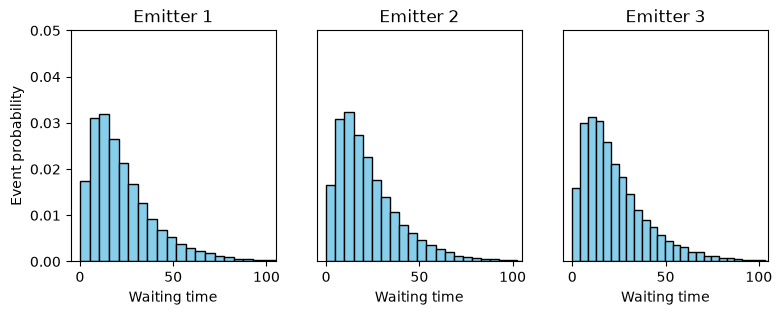

In [9]:
plt.figure(figsize=(9, 3.0))

plt.subplot(1,3,1)
plt.hist(wtime1, density=True, bins=40, color='skyblue', edgecolor='black')
plt.xlim([-5,105])
plt.ylim([0,0.05])
plt.title("Emitter 1")
plt.xlabel("Waiting time")
plt.ylabel("Event probability")

plt.subplot(1,3,2)
plt.hist(wtime2, density=True, bins=40, color='skyblue', edgecolor='black')
plt.xlim([-5,105])
plt.ylim([0,0.05])
plt.title("Emitter 2")
plt.xlabel("Waiting time")
plt.yticks([])

plt.subplot(1,3,3)
plt.hist(wtime3, density=True, bins=40, color='skyblue', edgecolor='black')
plt.xlim([-5,105])
plt.ylim([0,0.05])
plt.title("Emitter 3")
plt.xlabel("Waiting time")
plt.yticks([])

plt.show()

**Waiting time distribution of all photons**

If all photons detected by the detector are counted, we have a different distribution.  It seems close to poisson distribution.

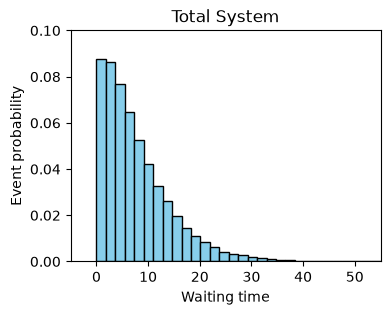

In [10]:
plt.figure(figsize=(4,3))
plt.hist(wtimes, density=True, bins=40, color='skyblue', edgecolor='black')
plt.xlim([-5,55])
plt.ylim([0,0.1])
plt.title("Total System")
plt.xlabel("Waiting time")
plt.ylabel("Event probability")
plt.show()

## Second order coherence

The coherence function $g^{(2)}(\tau)$ is evaluated from the photon counting statistics.

In [11]:
#--- calculate histogram
def hist(t,dtau,count):
    # ordered pairs, positive delay
    for i in range(t.size): 
        dt = t[i + 1:] - t[i]
        window = dt < tau_max
        if not np.any(window):
            continue
        b = np.floor(dt[window]/dtau).astype(int)
        np.add.at(count, b, 1)
    return

#--- counting parameters
tau_max = 40
dtau = 0.5

#--- edges of bins
edges = np.arange(0.0, tau_max + dtau, dtau)

#--- counting storages
count1 = np.zeros( edges.size - 1)  # emitter 1
count2 = np.zeros( edges.size - 1)  # emitter 2
count3 = np.zeros( edges.size - 1)  # emitter 3
counts = np.zeros( edges.size - 1)  # all emitters

#--- extract data from multiple runs
click1=0
click2=0
click3=0
clicks=0

for k in range(ntraj):
    tj = np.asarray(res.col_times[k])
    ch = np.asarray(res.col_which[k])
    t1 = tj[ch == 3]
    t2 = tj[ch == 4]
    t3 = tj[ch == 5]
    ts = tj[(ch == 3) | (ch == 4) | (ch == 5)]
    # emitter 1
    hist(t1,dtau,count1)
    click1+=t1.size
    # emitter 2
    hist(t2,dtau,count2)
    click2+=t2.size
    # emitter 3
    hist(t3,dtau,count3)
    click3+=t3.size
    # all emitters
    hist(ts,dtau,counts)
    clicks+=ts.size

#--- normalize the counts
norm = click1**2 / tlist[-1] / ntraj * dtau
g2_1 = count1 / norm
norm = click2**2 / tlist[-1] / ntraj * dtau
g2_2 = count2 / norm
norm = click3**2 / tlist[-1] / ntraj * dtau
g2_3 = count3 / norm
norm = clicks**2 / tlist[-1] / ntraj * dtau
g2_s = counts / norm
tau = 0.5 * (edges[:-1] + edges[1:]) 


In [12]:
print("no-delay coherence")
print("   emitter       g^2(0)")
print("{0:12s}   {1:7.3f}".format("   emitter 1", g2_1[0]))
print("{0:12s}   {1:7.3f}".format("   emitter 2", g2_2[0]))
print("{0:12s}   {1:7.3f}".format("   emitter 3", g2_3[0]))
print("{0:12s}   {1:7.3f}".format("all emitters", g2_s[0]))

no-delay coherence
   emitter       g^2(0)
   emitter 1     0.051
   emitter 2     0.057
   emitter 3     0.054
all emitters     0.683



**Plotting $g^{(2)}(\tau)$**

The coherence function based on photons from individual emitters shows strong anti-bunching but if all photons  from the three emitters are counted, the anti-bunching feature is significantly reduced as the theory predicts.  The no-delay coherence from the Monte Carlo method is about 0.67 in a good agreement with theoretical value $\tfrac23$.

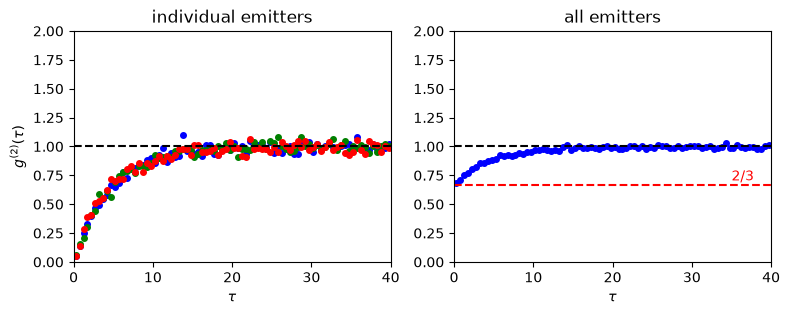

In [13]:
# g2 for photons from each emitters
plt.figure(figsize=(9, 3))
plt.subplot(1,2,1)
plt.title("individual emitters")
plt.ylim([0,2])
# g2_single = 1-np.exp(-gamma0*x1)
# plt.plot(x1,g2_single,ls='--',color='k')
plt.plot(tau,g2_1, ls='', marker='o', markersize=4, markerfacecolor='b', markeredgecolor='b',label="emitter 1")
plt.plot(tau,g2_2, ls='', marker='o', markersize=4, markerfacecolor='g', markeredgecolor='g',label="emitter 2")
plt.plot(tau,g2_3, ls='', marker='o', markersize=4, markerfacecolor='r', markeredgecolor='r',label="emitter 3")
plt.xlim([0,tau_max])
plt.xlabel(r"$\tau$")
plt.ylabel(r"$g^{(2)}(\tau)$")
plt.axhline(y=1, color='k', linestyle='--')

# g2 of all photons from the three emitters
plt.subplot(1,2,2)
plt.title("all emitters")
#g2_single = 1-np.exp(-gamma0*xs)
plt.ylim([0,2.0])
plt.plot(tau,g2_s, ls='', marker='o', markersize=4, markerfacecolor='b', markeredgecolor='b',label="all emitters")
plt.xlim([0,tau_max])
plt.xlabel(r"$\tau$")
plt.ylabel("")
plt.axhline(y=1, color='k', linestyle='--')
plt.axhline(y=2/3, color='r', linestyle='--')
plt.text(35,0.7,"$2/3$",color="r")
plt.show()